<a href="https://colab.research.google.com/github/Spiky03/ML-project-2025/blob/Spiky/XS_knowledge_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Knowledge Distillation: Ensemble Teachers → Tiny MLP Student

In [ ]:
#@title Imports
!pip install torch torchvision scikit-learn tqdm matplotlib pandas

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import random

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
#@title 1. Dataset MNIST ---
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

X = train_dataset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y = train_dataset.targets.numpy().astype(np.int64)
X_test = test_dataset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy().astype(np.int64)

# Smaller training subset for speed — keep a validation split
X_small, X_unused, y_small, y_unused = train_test_split(X, y, train_size=10000, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_small, y_small, train_size=0.9, stratify=y_small, random_state=SEED)

In [ ]:
#@title 2. Teacher Models
print("Training teacher models...")

rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

svm = SVC(probability=True, kernel="rbf", random_state=SEED)
svm_cal = CalibratedClassifierCV(svm, cv=3)
svm_cal.fit(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)

# Quick accuracies on validation to sanity-check
def ensemble_predict_proba_array(models, X_in):
    probas = [m.predict_proba(X_in) for m in models]
    return np.mean(probas, axis=0)

teachers = [rf, svm_cal, knn]
val_ens_probs = ensemble_predict_proba_array(teachers, X_val)
val_ens_pred = val_ens_probs.argmax(axis=1)
print("Validation ensemble accuracy:", accuracy_score(y_val, val_ens_pred))



Training teacher models...
Validation ensemble accuracy: 0.953


In [ ]:
#@title 3. Dataloader
train_tensor = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
    torch.tensor(ensemble_predict_proba_array(teachers, X_train), dtype=torch.float32)  # original probs
)
val_tensor = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long),
    torch.tensor(ensemble_predict_proba_array(teachers, X_val), dtype=torch.float32)
)
train_loader = DataLoader(train_tensor, batch_size=128, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_tensor, batch_size=256, shuffle=False, pin_memory=True)

In [ ]:
#@title 4. Student MLP
class StudentNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def distillation_loss(student_logits, labels, teacher_probs, T=3.0, alpha=0.5, eps=1e-8):
    # Hard-label cross-entropy
    ce_loss = F.cross_entropy(student_logits, labels)

    # Student log-probabilities with temperature
    student_log_soft = F.log_softmax(student_logits / T, dim=1)

    # Convert teacher probs -> soft targets using log(probs)/T then softmax
    # This is numerically stable and equivalent to dividing teacher logits by T.
    teacher_probs = teacher_probs.clamp(min=eps)
    teacher_soft = F.softmax(torch.log(teacher_probs) / T, dim=1)

    # KL divergence expects log-probs (input) and probs (target). Multiply by T^2 per distillation convention.
    kl = F.kl_div(student_log_soft, teacher_soft, reduction='batchmean') * (T**2)
    return alpha * ce_loss + (1 - alpha) * kl

In [ ]:
#@title 5. Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student = StudentNet().to(device)
optimizer = optim.Adam(student.parameters(), lr=1e-3)

T = 3.0
alpha = 0.5
epochs = 15

history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    student.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    train_loss = 0.0
    for xb, yb, tb in pbar:
        xb, yb, tb = xb.to(device), yb.to(device), tb.to(device)
        optimizer.zero_grad()
        logits = student(xb)
        loss = distillation_loss(logits, yb, tb, T=T, alpha=alpha)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    history["train_loss"].append(train_loss)

    # validation
    student.eval()
    val_loss = 0.0
    y_preds = []
    y_trues = []
    with torch.no_grad():
        for xb, yb, tb in val_loader:
            xb, yb, tb = xb.to(device), yb.to(device), tb.to(device)
            logits = student(xb)
            loss = distillation_loss(logits, yb, tb, T=T, alpha=alpha)
            val_loss += loss.item() * xb.size(0)
            y_preds.append(logits.argmax(dim=1).cpu().numpy())
            y_trues.append(yb.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    y_preds = np.concatenate(y_preds)
    y_trues = np.concatenate(y_trues)
    val_acc = accuracy_score(y_trues, y_preds)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} — train_loss: {train_loss:.4f} — val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f}")

Epoch 1/15:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/15 — train_loss: 2.2016 — val_loss: 1.0670 — val_acc: 0.8620


Epoch 2/15:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 2/15 — train_loss: 1.0363 — val_loss: 0.9399 — val_acc: 0.8990


Epoch 3/15:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 13/15 — train_loss: 0.6670 — val_loss: 0.7860 — val_acc: 0.9520


Epoch 14/15:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 14/15 — train_loss: 0.6537 — val_loss: 0.7776 — val_acc: 0.9470


Epoch 15/15:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 15/15 — train_loss: 0.6441 — val_loss: 0.7865 — val_acc: 0.9480


In [ ]:
student.eval()
with torch.no_grad():
    logits_test = student(torch.tensor(X_test, dtype=torch.float32).to(device))
    preds_test = logits_test.argmax(dim=1).cpu().numpy()

acc_student = accuracy_score(y_test, preds_test)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_svm = accuracy_score(y_test, svm_cal.predict(X_test))
acc_knn = accuracy_score(y_test, knn.predict(X_test))
acc_ens = accuracy_score(y_test, ensemble_predict_proba_array(teachers, X_test).argmax(axis=1))

summary = pd.DataFrame({
    "Model": ["Random Forest", "SVM (calibrated)", "KNN", "Ensemble", "Student (KD)"],
    "Test accuracy": [acc_rf, acc_svm, acc_knn, acc_ens, acc_student]
})
display(summary.style.format({"Test accuracy": "{:.4f}"}))

,Model,Test accuracy
0,Random Forest,0.9487
1,SVM (calibrated),0.9582
2,KNN,0.9434
3,Ensemble,0.9609
4,Student (KD),0.9530


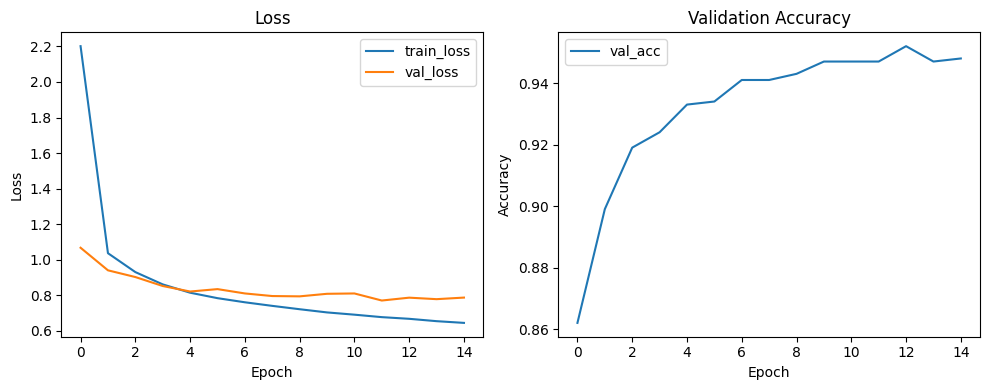

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
torch.save(student.state_dict(), "student_mlp_kd.pth")